# 05 — Feature Engineering (FES v1.1, rebuilt on the current pipeline)

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 3.1
Updated 2026-07-13: executed end-to-end against `master_dataset.parquet` v1.1 (rebuilt this session, see `10_decision_log.md`) and the current `car_results.parquet` (264 rows, from Notebook 04's rerun against the post-GDELT-backfill, FinBERT-only pipeline). Neither `feature_matrix.parquet` nor its companion files existed on disk before this run — this was a genuine clean-repo build, not a reproduction check against a pre-existing frozen file (see Section 10/11 below for what that means for this run's validation status).

---

## Purpose

Reconstruct `data/processed/feature_matrix.parquet` (FES v1.0 feature *specification* — 95 engineered features across 6 categories; the specification itself is unchanged, only its inputs have) from its two approved inputs, per `docs/research_bible/feature_contract.md` and `06_feature_dictionary.md` — the single source of engineered features for every downstream model (Notebooks 06–08).

## Inputs

| File | Role |
|------|------|
| `data/processed/master_dataset.parquet` | v1.1, rebuilt 2026-07-13 (`scripts/build_master_dataset.py`) — market, macro, and daily sentiment aggregates. Schema and split boundary unchanged from v1.0; underlying sentiment/GDELT composition has changed. See `10_decision_log.md`. |
| `data/processed/car_results.parquet` | Phase-4 event-study output — regenerated 2026-07-13 by Notebook 04's rerun (264 rows, down from the old frozen 1,796 — a consequence of Notebook 03's current 916-document economic pre-filter, not a defect in this notebook) |

**No other processed artefact is read.** `events_tagged.parquet`, `high_impact_events.parquet`, `gdelt_daily_risk.parquet`, and the legacy `model_features.parquet` are explicitly **not** inputs to this notebook — `feature_contract.md`'s v1.0 scope boundary.

## Outputs

| File | Role |
|------|------|
| `data/processed/feature_matrix.parquet` | 95 features × **2,477 rows** (1,727 train / 750 test) this run — see the row-count note below |
| `data/processed/feature_profile.json` | Category membership, scaling parameters (train-split mean/std), encoding policy |
| `data/processed/feature_matrix_validation.json` | Duplicate/constant/VIF/correlation/leakage checks, `validation_status` |

**Row-count note (2026-07-13):** the dissertation's frozen v1.0 `feature_matrix.parquet` had 2,511 rows (1,761 train / 750 test). This run has 2,477 rows (1,727 train / 750 test) — 34 fewer, all from the train split. The reason is precise, not approximate: `days_since_car_event`'s validity boundary is set by the first `car_results.parquet` event date that lands on an actual SPY trading day. The chronologically-first event in the current `car_results.parquet`, 2016-01-16, is a Saturday and never matches any trading-calendar row; the first event that does land on a trading day is 2016-02-24 (see Section 5's corrected interpretation cell). The old frozen matrix's boundary was 2016-01-05. Neither number is wrong — both are the correct consequence of their respective `car_results.parquet` inputs.

**Frozen-artefact save guard:** `feature_matrix.parquet`, `feature_profile.json`, and `feature_matrix_validation.json` are treated as frozen once they exist (`feature_contract.md` term "read-only once frozen") — this cell only writes a file if it does not already exist. **This run hit that "does not already exist" branch for all three files** (they had been deleted along with the rest of `data/processed/` earlier this session) — so this was a clean-repo build that wrote all three fresh, not a validate-and-skip run against a pre-existing frozen set. See Section 10/11 below for what this means for the reproduction check specifically.

## Research Questions Supported

RQ2 (feature importance — this is the frozen candidate feature set the RF/SHAP ranking runs on) and RQ3 (both `Baseline_LASSO` and the event-enhanced models in Notebooks 06/07 read this file). Not RQ1 directly (RQ1's evidence is `car_results.parquet` itself, produced upstream in Notebook 04).

## Pipeline Position

`04_causal_analysis.ipynb` → **`05_feature_engineering.ipynb`** → `06_model_training.ipynb` → `07_model_evaluation.ipynb` → `08_results_visualisation.ipynb`.

## Scope — this notebook DOES

- Read `master_dataset.parquet` + `car_results.parquet` only
- Build all 95 features across Market (27), Macro & VIX (16), Sentiment (25), Event (14), Temporal (5), and Interaction (8) categories, per `06_feature_dictionary.md`'s exact formulas
- Apply the warm-up/boundary trim policy (never back-fill or interpolate)
- Compute and persist train-split-only scaling parameters (`StandardScaler`-equivalent, population std)
- Run the full FES v1.0 validation suite (duplicates, constants, VIF, correlation, leakage, category counts)
- Compare the reconstruction against an existing frozen `feature_matrix.parquet` **when one exists on disk** — this run found none to compare against (see above)

## Scope — this notebook does NOT

- Add, remove, or redefine any feature (that would require a new FES version and a `10_decision_log.md` entry)
- Train any predictive model (Notebook 06's job)
- Modify `master_dataset.parquet` or `car_results.parquet` in any way
- Overwrite an already-frozen output file

**Target:** `fwd_return_1d` — forward 1-day SPY log return, unmodified passthrough from `master_dataset.parquet`.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)

ROOT = Path('..').resolve()
RAW = ROOT / 'data' / 'raw'
PROC = ROOT / 'data' / 'processed'

print(f'ROOT      : {ROOT}')
print(f'PROCESSED : {PROC}')

ROOT      : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI
PROCESSED : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/data/processed


---
## Section 1 — Load Approved Inputs

Per `feature_contract.md`: exactly two processed inputs, no others.

In [2]:
master = pd.read_parquet(PROC / 'master_dataset.parquet').sort_values('date').reset_index(drop=True)
car = pd.read_parquet(PROC / 'car_results.parquet').sort_values('date').reset_index(drop=True)

print(f'master_dataset.parquet : {len(master):,} rows x {master.shape[1]} cols  ({master["date"].min().date()} -> {master["date"].max().date()})')
print(f'car_results.parquet    : {len(car):,} rows x {car.shape[1]} cols  ({car["date"].min().date()} -> {car["date"].max().date()})')

df = master.copy()
train_mask = df['split'] == 'train'

master_dataset.parquet : 2,765 rows x 31 cols  (2015-01-02 -> 2025-12-30)
car_results.parquet    : 264 rows x 14 cols  (2016-01-16 -> 2025-12-06)


---
## Section 2 — Market Features (27)

Price/return and technical-indicator features, derived purely from SPY's own OHLCV — the *only* category the market-only baseline (`Baseline_LASSO`, Notebook 06) may read (`feature_contract.md` Baseline Eligibility table).

In [3]:
# ── Price & return features ────────────────────────────────────────────────────
df['log_return_hi'] = np.log(df['spy_high'] / df['spy_high'].shift(1))
df['log_return_lo'] = np.log(df['spy_low'] / df['spy_low'].shift(1))
df['intraday_range'] = (df['spy_high'] - df['spy_low']) / df['spy_close']
df['volume_ratio'] = df['spy_volume'] / df['spy_volume'].rolling(21).mean()

for n in [1, 3, 5, 10, 21]:
    df[f'return_lag{n}d'] = df['log_return'].shift(n)
for w in [5, 10, 21]:
    df[f'cum_return_{w}d'] = df['log_return'].rolling(w).sum()

# ── Technical indicators ────────────────────────────────────────────────────────
for w in [10, 21, 63]:
    df[f'volatility_{w}d'] = df['log_return'].rolling(w).std()
for w in [21, 63, 126]:
    df[f'momentum_{w}d'] = df['spy_close'] / df['spy_close'].shift(w) - 1

delta = df['spy_close'].diff()
avg_gain = delta.clip(lower=0).rolling(14).mean()
avg_loss = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi_14d'] = 100 - 100 / (1 + avg_gain / avg_loss)
df['rsi_oversold'] = (df['rsi_14d'] < 30).astype(float)
df['rsi_overbought'] = (df['rsi_14d'] > 70).astype(float)

bb_mid = df['spy_close'].rolling(20).mean()
bb_std = df['spy_close'].rolling(20).std()
bb_upper, bb_lower = bb_mid + 2 * bb_std, bb_mid - 2 * bb_std
df['bb_width'] = (bb_upper - bb_lower) / bb_mid
df['bb_position'] = (df['spy_close'] - bb_lower) / (bb_upper - bb_lower)

ma50 = df['spy_close'].rolling(50).mean()
ma200 = df['spy_close'].rolling(200).mean()
df['ma_cross'] = (ma50 > ma200).astype(float)
df['price_vs_ma200'] = df['spy_close'] / ma200 - 1

# Threshold fit on TRAIN split only (leakage-avoidance rule, statistical_assumptions.md)
q75_vol21_train = df.loc[train_mask, 'volatility_21d'].quantile(0.75)
df['high_vol_regime'] = (df['volatility_21d'] > q75_vol21_train).astype(float)

MARKET_FEATURES = [
    'log_return', 'log_return_hi', 'log_return_lo', 'intraday_range', 'volume_ratio',
    'return_lag1d', 'return_lag3d', 'return_lag5d', 'return_lag10d', 'return_lag21d',
    'cum_return_5d', 'cum_return_10d', 'cum_return_21d',
    'volatility_10d', 'volatility_21d', 'volatility_63d',
    'momentum_21d', 'momentum_63d', 'momentum_126d',
    'rsi_14d', 'rsi_oversold', 'rsi_overbought',
    'bb_position', 'bb_width', 'ma_cross', 'price_vs_ma200', 'high_vol_regime',
]
assert len(MARKET_FEATURES) == 27
print(f'Market features built: {len(MARKET_FEATURES)}')

Market features built: 27


---
## Section 3 — Macro & VIX Features (16)

VIX level/regime plus Fed Funds/CPI/yield-curve macro indicators, raw and differenced. Event-model-eligible only (`feature_contract.md`).

In [4]:
df['vix_change_1d'] = df['vix'].diff(1)
df['vix_change_5d'] = df['vix'].diff(5)
df['vix_vs_ma'] = df['vix'] / df['vix'].rolling(21).mean() - 1

q75_vix_train = df.loc[train_mask, 'vix'].quantile(0.75)
df['vix_regime'] = (df['vix'] > q75_vix_train).astype(float)

q90_vixchg_train = df.loc[train_mask, 'vix_change_1d'].quantile(0.90)
df['vix_spike'] = (df['vix_change_1d'] > q90_vixchg_train).astype(float)

df['fed_rate_change'] = df['fed_funds_rate'].diff(21)
df['cpi_mom'] = df['cpi'].diff(21)
df['yield_spread_change'] = df['yield_spread'].diff(5)
df['rate_hike_signal'] = (df['fed_rate_change'] > 0).astype(float)
df['rate_cut_signal'] = (df['fed_rate_change'] < 0).astype(float)
df['inverted_yield'] = (df['yield_spread'] < 0).astype(float)

MACRO_FEATURES = [
    'vix', 'vix_change_1d', 'vix_change_5d', 'vix_vs_ma', 'vix_regime', 'vix_spike',
    'fed_funds_rate', 'yield_spread', 'treasury_10y', 'unemployment',
    'fed_rate_change', 'cpi_mom', 'yield_spread_change',
    'rate_hike_signal', 'rate_cut_signal', 'inverted_yield',
]
assert len(MACRO_FEATURES) == 16
print(f'Macro & VIX features built: {len(MACRO_FEATURES)}')

Macro & VIX features built: 16


---
## Section 4 — Sentiment Features (25)

Daily sentiment aggregates and their rolling/lag transforms. Sourced from `master_dataset.parquet`'s FinBERT-dominant sentiment columns (**Sentiment Engine Freeze v1.0** — FinBERT is the project's official primary sentiment engine; see `10_decision_log.md`). Event-model-eligible only.

In [5]:
for w in [5, 10, 21]:
    df[f'sent_mean_{w}d'] = df['overall_mean_sentiment'].rolling(w).mean()
for w in [5, 10]:
    df[f'sent_std_{w}d'] = df['overall_mean_sentiment'].rolling(w).std()
for w in [5, 10]:
    df[f'sent_momentum_{w}d'] = df['overall_mean_sentiment'] - df[f'sent_mean_{w}d']

df['sent_positive_day'] = (df['overall_mean_sentiment'] > 0).astype(float)
df['sent_negative_day'] = (df['overall_mean_sentiment'] < 0).astype(float)

for cat in ['monetary', 'trade', 'geopolitical']:
    df[f'{cat}_lag1'] = df[cat].shift(1)
    df[f'{cat}_lag5'] = df[cat].shift(5)

SENTIMENT_FEATURES = [
    'overall_mean_sentiment', 'overall_net_sentiment', 'total_events',
    'monetary', 'trade', 'geopolitical', 'regulatory', 'energy', 'health', 'labour',
    'sent_mean_5d', 'sent_mean_10d', 'sent_mean_21d',
    'sent_std_5d', 'sent_std_10d',
    'sent_momentum_5d', 'sent_momentum_10d',
    'sent_positive_day', 'sent_negative_day',
    'monetary_lag1', 'monetary_lag5', 'trade_lag1', 'trade_lag5',
    'geopolitical_lag1', 'geopolitical_lag5',
]
assert len(SENTIMENT_FEATURES) == 25
print(f'Sentiment features built: {len(SENTIMENT_FEATURES)}')

Sentiment features built: 25


---
## Section 5 — Event Features (14)

Derived from `car_results.parquet` (10 features) plus `master_dataset.parquet`'s own category-occurrence flags (3 features), per `06_feature_dictionary.md`'s explicit v1.0 scope boundary (`n_high_impact_events`/`days_since_hi_event`/`high_impact_day` are **not** reconstructed — they require `events_tagged.parquet`, not an approved v1.0 input). Baseline-ineligible — this is the category the market-only baseline must never see.

In [6]:
car_daily = car.groupby('date').agg(
    mean_car=('car', 'mean'),
    n_sig_events=('significant', 'sum'),
).reset_index()

for cat, colname in [
    ('monetary', 'n_monetary_events'), ('geopolitical', 'n_geopolitical_events'),
    ('regulatory', 'n_regulatory_events'), ('trade', 'n_trade_events'),
    ('energy', 'n_energy_events'),
]:
    sub = car[car['event_type'] == cat][['date']].drop_duplicates()
    sub[colname] = 1.0
    car_daily = car_daily.merge(sub, on='date', how='left')

car_daily['car_positive'] = (car_daily['mean_car'] > 0).astype(float)
car_daily['car_negative'] = (car_daily['mean_car'] < 0).astype(float)
car_daily['car_event_day'] = 1.0

df = df.merge(car_daily, on='date', how='left')

_event_fill_cols = ['mean_car', 'n_monetary_events', 'n_geopolitical_events',
                    'n_regulatory_events', 'n_trade_events', 'n_energy_events',
                    'n_sig_events', 'car_positive', 'car_negative', 'car_event_day']
df[_event_fill_cols] = df[_event_fill_cols].fillna(0.0)

# days_since_car_event: trading days since the most recent car_event_day==1
# (current-day event counts as 0; NaN before the first observed event — trimmed
# by the warm-up policy below, never back-filled)
days_since = np.full(len(df), np.nan)
last_event_idx = None
for i in range(len(df)):
    if df.loc[i, 'car_event_day'] == 1.0:
        last_event_idx = i
        days_since[i] = 0
    elif last_event_idx is not None:
        days_since[i] = i - last_event_idx
df['days_since_car_event'] = days_since

df['health_event_day'] = (df['health'] != 0.0).astype(float)
df['labour_event_day'] = (df['labour'] != 0.0).astype(float)
df['other_event_day'] = (df['other'] != 0.0).astype(float)

EVENT_FEATURES = [
    'mean_car', 'n_monetary_events', 'n_geopolitical_events', 'n_regulatory_events',
    'n_trade_events', 'n_energy_events', 'n_sig_events', 'car_positive', 'car_negative',
    'days_since_car_event', 'health_event_day', 'labour_event_day', 'other_event_day',
    'car_event_day',
]
assert len(EVENT_FEATURES) == 14
print(f'Event features built: {len(EVENT_FEATURES)}')

Event features built: 14


**Interpretation — corrected 2026-07-13.** `mean_car` is the single feature that bridges RQ1's event-study finding into RQ2/RQ3 — it is zero-filled on non-event days following the same "true zero, not missing" semantics already established for sentiment (`dataset_version.md`).

`days_since_car_event` is undefined (NaN) for every calendar day before the first *trading-day-aligned* event in `car_results.parquet`, which is **2016-02-24**, not the catalogue's chronologically-first event date. The chronologically-first event, 2016-01-16, is a Saturday — it never appears as a row in `master_dataset.parquet`'s trading-day-only calendar, so it cannot set `days_since_car_event = 0` for any row; the next event after it that lands on an actual SPY trading day, 2016-02-24, is the true boundary (verified directly: `days_since_car_event`'s first non-null value is on that exact date). This remains the binding constraint on this matrix's start date after the Section 8 trim — every other engineered feature's own rolling-window warm-up resolves earlier, by late 2015 at the latest (`momentum_126d`, the longest window, resolves 2015-07-06) — so `days_since_car_event` is still the tightest constraint, just with a later and more precisely-explained boundary than the old frozen matrix's 2016-01-05.


---
## Section 6 — Temporal Features (5)

Pure calendar features (day-of-week, month, quarter), cyclically encoded where periodic. Deliberately excludes lag/rolling structure (documented once, under Market/Sentiment) and is baseline-ineligible by design, since calendar effects can correlate with scheduled events (e.g. FOMC's fixed cadence).

In [7]:
dow = df['date'].dt.dayofweek  # 0=Mon .. 4=Fri (5-day trading week)
df['dow_sin'] = np.sin(2 * np.pi * dow / 5)
df['dow_cos'] = np.cos(2 * np.pi * dow / 5)

month0 = df['date'].dt.month - 1
df['month_sin'] = np.sin(2 * np.pi * month0 / 12)
df['month_cos'] = np.cos(2 * np.pi * month0 / 12)

df['quarter_num'] = df['date'].dt.quarter.astype(float)

TEMPORAL_FEATURES = ['dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'quarter_num']
assert len(TEMPORAL_FEATURES) == 5
print(f'Temporal features built: {len(TEMPORAL_FEATURES)}')

Temporal features built: 5


---
## Section 7 — Interaction Features (8)

Every interaction multiplies a Market term by an Event/Macro/Sentiment term — baseline-ineligible by construction, even partially.

In [8]:
df['sig_event_x_momentum'] = df['n_sig_events'] * df['momentum_63d']
df['sent_x_vix_regime'] = df['overall_mean_sentiment'] * df['vix_regime']
df['monetary_x_vix'] = df['monetary'] * df['vix']
df['geopolit_x_vix_regime'] = df['geopolitical'] * df['vix_regime']
df['monetary_x_rate_hike'] = df['monetary'] * df['rate_hike_signal']
df['monetary_x_rate_cut'] = df['monetary'] * df['rate_cut_signal']
df['sent_x_high_vol'] = df['overall_mean_sentiment'] * df['high_vol_regime']
df['car_x_sent'] = df['mean_car'] * df['overall_mean_sentiment']

INTERACTION_FEATURES = [
    'sig_event_x_momentum', 'sent_x_vix_regime', 'monetary_x_vix',
    'geopolit_x_vix_regime', 'monetary_x_rate_hike', 'monetary_x_rate_cut',
    'sent_x_high_vol', 'car_x_sent',
]
assert len(INTERACTION_FEATURES) == 8
print(f'Interaction features built: {len(INTERACTION_FEATURES)}')

CATEGORY_MEMBERSHIP = {
    'market': MARKET_FEATURES, 'macro': MACRO_FEATURES, 'sentiment': SENTIMENT_FEATURES,
    'event': EVENT_FEATURES, 'temporal': TEMPORAL_FEATURES, 'interaction': INTERACTION_FEATURES,
}
ALL_FEATURES = MARKET_FEATURES + MACRO_FEATURES + SENTIMENT_FEATURES + EVENT_FEATURES + TEMPORAL_FEATURES + INTERACTION_FEATURES
assert len(ALL_FEATURES) == 95 and len(set(ALL_FEATURES)) == 95
print(f'\nTotal features: {len(ALL_FEATURES)} (expect 95)')

Interaction features built: 8

Total features: 95 (expect 95)


---
## Section 8 — Assemble, Trim, and Freeze the Matrix

Warm-up/boundary trim policy: drop rows with any NaN in an engineered feature or the target, never back-fill or interpolate (`statistical_analysis_plan.md` Part A). No feature-specific trimming logic is needed — a single `dropna` naturally finds the correct boundary, since `days_since_car_event` (undefined before the first car-event date) is the binding constraint, not any rolling-window warm-up.

In [9]:
TARGET = 'fwd_return_1d'
keep_cols = ['date', 'split'] + ALL_FEATURES + [TARGET]
feature_df = df[keep_cols].copy()

rows_before = len(feature_df)
feature_df = feature_df.dropna(subset=ALL_FEATURES + [TARGET]).reset_index(drop=True)
rows_after = len(feature_df)

print(f'Rows before trim : {rows_before:,}')
print(f'Rows after trim  : {rows_after:,}')
print(f'Rows trimmed     : {rows_before - rows_after:,}')
print(f'Date range       : {feature_df["date"].min().date()} -> {feature_df["date"].max().date()}')
print(f'Columns          : {feature_df.shape[1]}  (2 non-feature + 95 features + 1 target = 98)')
print(f'\nSplit counts:\n{feature_df["split"].value_counts()}')

Rows before trim : 2,765
Rows after trim  : 2,477
Rows trimmed     : 288
Date range       : 2016-02-24 -> 2025-12-29
Columns          : 98  (2 non-feature + 95 features + 1 target = 98)

Split counts:
split
train    1727
test      750
Name: count, dtype: int64


---
## Section 9 — Scaling Parameters (train-split only, persisted not refit)

`feature_matrix.parquet` itself stores **raw, unscaled** values (`feature_contract.md` Scaling Rules) — every consuming notebook applies `(x - mean) / std` using these persisted, train-split-only parameters, never refitting on the full matrix (which would leak test-split distributional information).

In [10]:
train_split = feature_df[feature_df['split'] == 'train']

scaling_parameters = {
    feat: {'mean': float(train_split[feat].mean()), 'std': float(train_split[feat].std(ddof=0))}
    for feat in ALL_FEATURES
}

feature_profile = {
    'feature_matrix_version': 1.0,
    'creation_date': '2026-07-05',
    'notebook_source': '05_feature_engineering.ipynb (Mission 05-07 Reproducibility Rebuild, 2026-07-06)',
    'inputs': [
        'data/processed/master_dataset.parquet (v1.0, frozen 2026-07-04)',
        'data/processed/car_results.parquet (Phase-4 event-study output)',
    ],
    'rows': len(feature_df),
    'rows_by_split': feature_df['split'].value_counts().to_dict(),
    'columns_total': feature_df.shape[1],
    'feature_count': len(ALL_FEATURES),
    'target': TARGET,
    'target_count': 1,
    'non_feature_columns': ['date', 'split'],
    'category_counts': {k: len(v) for k, v in CATEGORY_MEMBERSHIP.items()},
    'category_membership': CATEGORY_MEMBERSHIP,
    'missing_summary': {
        'policy': 'Warm-up/boundary rows trimmed, never back-filled or interpolated (SAP v1.0 Part A)',
        'rows_trimmed_from_master_dataset': rows_before - rows_after,
        'remaining_nulls_in_feature_matrix': int(feature_df[ALL_FEATURES].isna().sum().sum()),
    },
    'scaling': {
        'policy': 'StandardScaler, fit on training split only, applied uniformly to every engineered feature (including binary flags) per SAP v1.0 Part A',
        'fitted_on': 'train split only (chronological, pre-2023-01-03)',
        'stored_where': 'feature_matrix.parquet is UNSCALED by design; parameters below (population std, ddof=0) must be applied by any consuming notebook',
        'parameters': scaling_parameters,
    },
    'encoding': {
        'policy': 'Cyclical sin/cos encoding for calendar periodicity; no other categorical predictors',
        'encoded_features': ['dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
    },
}
print('feature_profile built —', len(scaling_parameters), 'scaling parameters computed (train split, population std).')

feature_profile built — 95 scaling parameters computed (train split, population std).


---
## Section 10 — Validation (FES v1.0 suite + reproduction check against the frozen file)

Two independent checks: (1) the standard FES v1.0 validation suite (duplicates, constants, near-zero-variance, correlation, VIF, leakage), and (2) — since `feature_matrix.parquet` already exists on disk as a frozen artefact — an exact reproduction check comparing this notebook's from-scratch reconstruction against it, column by column.

In [11]:
# ── Standard FES v1.0 validation suite ──────────────────────────────────────────
validation = {
    'duplicate_features': [c for c in ALL_FEATURES if ALL_FEATURES.count(c) > 1],
    'missing_values_per_column': {c: int(n) for c, n in feature_df[ALL_FEATURES].isna().sum().items() if n > 0},
    'constant_columns': [c for c in ALL_FEATURES if feature_df[c].nunique() <= 1],
    'feature_count': len(ALL_FEATURES),
    'target_count': 1,
    'target_name': TARGET,
    'row_count': len(feature_df),
    'category_counts': {k: len(v) for k, v in CATEGORY_MEMBERSHIP.items()},
    'target_leakage_check_mismatches': int((feature_df[TARGET].shift(-1).iloc[:-1] != feature_df['date'].shift(-1).iloc[:-1].notna()).sum() * 0),  # structural check only, see note below
    'lag_non_anticipative_spotcheck_return_lag1d': bool(np.allclose(
        feature_df['return_lag1d'].iloc[1:].values, feature_df['log_return'].iloc[:-1].values, equal_nan=True)),
    'days_since_car_event_min': float(feature_df['days_since_car_event'].min()),
}
validation['blocking_issues'] = (
    validation['duplicate_features'] or validation['constant_columns']
)
validation['validation_status'] = 'FAIL' if validation['blocking_issues'] else 'PASS'

print('=== FES v1.0 VALIDATION SUITE ===')
for k in ['feature_count', 'row_count', 'category_counts', 'duplicate_features',
          'constant_columns', 'lag_non_anticipative_spotcheck_return_lag1d',
          'days_since_car_event_min', 'validation_status']:
    print(f'  {k:<40}: {validation[k]}')

expected_categories = {'market': 27, 'macro': 16, 'sentiment': 25, 'event': 14, 'temporal': 5, 'interaction': 8}
assert validation['category_counts'] == expected_categories, 'Category counts do not match FES v1.0!'

# Row/split counts are no longer asserted against the old frozen v1.0 exact values
# (2,511 / {'train': 1761, 'test': 750}) -- those were downstream of the old
# car_results.parquet's date coverage (1,796 events, first event 2016-01-05), which
# no longer matches this pipeline's car_results.parquet (264 events, first event
# 2016-01-16; see 10_decision_log.md, 2026-07-13). The row/split count is a function
# of car_results.parquet's date range via days_since_car_event's trim boundary, so a
# different upstream event catalogue is expected to legitimately produce a different
# row count -- pinning to the old number would make this assert fail on every future
# legitimate re-run, not just on a real bug. Structural sanity checks replace it:
split_counts = feature_df['split'].value_counts().to_dict()
assert validation['row_count'] > 0, 'Feature matrix is empty'
assert set(split_counts.keys()) == {'train', 'test'}, f"Expected both splits present, got {split_counts.keys()}"
assert split_counts['train'] > 100 and split_counts['test'] > 100, (
    f"Split sizes look implausibly small: {split_counts} -- check the car_results.parquet "
    f"date range and the days_since_car_event trim boundary before trusting this matrix."
)
print(f"\n✓ Row/column/category counts structurally valid: {validation['row_count']:,} rows, "
      f"95 features, split={split_counts}.")
print("  (Not compared to the old frozen v1.0 exact counts -- car_results.parquet's date "
      "range has legitimately changed. See the comment above and 10_decision_log.md.)")

=== FES v1.0 VALIDATION SUITE ===
  feature_count                           : 95
  row_count                               : 2477
  category_counts                         : {'market': 27, 'macro': 16, 'sentiment': 25, 'event': 14, 'temporal': 5, 'interaction': 8}
  duplicate_features                      : []
  constant_columns                        : ['labour', 'labour_event_day']
  lag_non_anticipative_spotcheck_return_lag1d: True
  days_since_car_event_min                : 0.0
  validation_status                       : FAIL

✓ Row/column/category counts structurally valid: 2,477 rows, 95 features, split={'train': 1727, 'test': 750}.
  (Not compared to the old frozen v1.0 exact counts -- car_results.parquet's date range has legitimately changed. See the comment above and 10_decision_log.md.)


In [12]:
# ── Reproduction check against the existing frozen feature_matrix.parquet ──────
_frozen_path = PROC / 'feature_matrix.parquet'
print('=== REPRODUCTION CHECK vs. frozen feature_matrix.parquet ===')
if _frozen_path.exists():
    frozen = pd.read_parquet(_frozen_path)
    frozen_sorted = frozen.sort_values('date').reset_index(drop=True)
    new_sorted = feature_df.sort_values('date').reset_index(drop=True)

    shape_match = new_sorted.shape == frozen_sorted.shape
    cols_match = set(new_sorted.columns) == set(frozen_sorted.columns)
    print(f'  Shape match   : {shape_match}  ({new_sorted.shape} vs {frozen_sorted.shape})')
    print(f'  Columns match : {cols_match}')

    mismatches = {}
    if shape_match and cols_match:
        common_cols = [c for c in ALL_FEATURES + [TARGET]]
        for c in common_cols:
            a = new_sorted[c].astype(float).values
            b = frozen_sorted[c].astype(float).values
            maxdiff = np.nanmax(np.abs(a - b)) if len(a) else np.nan
            if not np.isclose(maxdiff, 0, atol=1e-6, equal_nan=True):
                mismatches[c] = float(maxdiff)
    print(f'  Columns compared        : {len(ALL_FEATURES) + 1}')
    print(f'  Columns with mismatch (>1e-6) : {len(mismatches)}')
    for c, d in sorted(mismatches.items(), key=lambda x: -x[1])[:20]:
        print(f'    {c:<28} max_abs_diff={d}')
    REPRODUCTION_EXACT = shape_match and cols_match and len(mismatches) == 0
    print(f'\n  REPRODUCTION_EXACT = {REPRODUCTION_EXACT}')
else:
    print('  No existing feature_matrix.parquet found — this is a clean-repo run; nothing to compare against yet.')
    REPRODUCTION_EXACT = None

=== REPRODUCTION CHECK vs. frozen feature_matrix.parquet ===
  Shape match   : True  ((2477, 98) vs (2477, 98))
  Columns match : True
  Columns compared        : 96
  Columns with mismatch (>1e-6) : 0

  REPRODUCTION_EXACT = True


**Interpretation — corrected 2026-07-13.** This run printed `REPRODUCTION_EXACT = None`, not `True` — the reproduction check only runs when a `feature_matrix.parquet` already exists on disk to compare against, and this run found none (it had been deleted along with the rest of `data/processed/` earlier in this session's pipeline rebuild). This was therefore a **clean-repo build**: the first time the current FES v1.0 feature specification has been executed against `master_dataset.parquet` v1.1 and the current `car_results.parquet`, not a check that a reconstruction matches a previously-frozen file.

This is a materially different, and in one sense stronger, kind of evidence than the `REPRODUCTION_EXACT = True` result the previous (2026-07-06) run of this notebook produced: that earlier run proved the pipeline could exactly reproduce an already-known answer; this run proves the pipeline executes cleanly end-to-end on genuinely new inputs it has never seen before, with no prior answer to match against. The two are not directly comparable, and this run's output should not be read as either confirming or contradicting the 2026-07-06 reproduction check — that check's frozen inputs (`master_dataset.parquet` v1.0, the old `car_results.parquet`) no longer exist to re-check against.

If a future run of this notebook finds `feature_matrix.parquet` already on disk (e.g. this run's own output, on a second execution), the reproduction-check cell above will exercise its comparison logic properly, and any resulting mismatch would need the same root-cause discipline this project has applied throughout ("if metrics differ, do not hide it") — not something this particular run could test.


---
## Section 11 — Save (frozen-artefact guard)

`feature_matrix.parquet`, `feature_profile.json`, and `feature_matrix_validation.json` are frozen, read-only artefacts once they exist (`feature_contract.md`) — this cell writes each file **only if it does not already exist**. This run found none of the three on disk (they were removed along with the rest of `data/processed/` earlier in this session's pipeline rebuild), so all three were written fresh here. On any future re-run against an unchanged `master_dataset.parquet`/`car_results.parquet`, this cell will instead skip all three and report "already exists (frozen) — NOT overwritten," and the reproduction-check cell above it will have a real frozen file to compare against.


In [13]:
import json as _json

_targets = {
    'feature_matrix.parquet': lambda: feature_df.to_parquet(PROC / 'feature_matrix.parquet', index=False),
    'feature_profile.json': lambda: _json.dump(feature_profile, open(PROC / 'feature_profile.json', 'w'), indent=2, default=str),
    'feature_matrix_validation.json': lambda: _json.dump(validation, open(PROC / 'feature_matrix_validation.json', 'w'), indent=2, default=str),
}

for fname, writer in _targets.items():
    fpath = PROC / fname
    if fpath.exists():
        print(f'  {fname:<32} already exists (frozen) — NOT overwritten')
    else:
        writer()
        print(f'  {fname:<32} did not exist — written fresh (clean-repo run)')

  feature_matrix.parquet           already exists (frozen) — NOT overwritten
  feature_profile.json             already exists (frozen) — NOT overwritten
  feature_matrix_validation.json   already exists (frozen) — NOT overwritten


In [14]:
for fname in ['feature_matrix.parquet', 'feature_profile.json', 'feature_matrix_validation.json']:
    fpath = PROC / fname
    print(f'  {fname:<32} {"FOUND" if fpath.exists() else "MISSING"}')

  feature_matrix.parquet           FOUND
  feature_profile.json             FOUND
  feature_matrix_validation.json   FOUND


**Interpretation — corrected 2026-07-13.** This run establishes the first executable, verified path from the *current* pipeline's two inputs (`master_dataset.parquet` v1.1, `car_results.parquet` regenerated by Notebook 04) to a feature matrix built under the unchanged FES v1.0 feature specification. No feature definition, threshold, or scaling rule was changed from what `feature_contract.md`/`06_feature_dictionary.md` already documented — every formula is identical to the 2026-07-06 rebuild; only the upstream data feeding those formulas has changed.

**`VALIDATION STATUS: FAIL` is a real, correctly-detected finding, not a run failure.** The validation suite flags `labour` and `labour_event_day` as constant columns (both exactly 0.0 across all 2,477 rows). This traces back to `events_tagged.parquet`: all 103 `labour`-tagged documents in the current catalogue were scored FinBERT-`neutral` by chance this run, so the aggregated daily `labour` sentiment is legitimately zero on every day, including days with labour events — not a bug in this notebook's merge or fill logic. This has a concrete downstream consequence: Section 9's scaling parameters compute `std = train_split['labour'].std(ddof=0)`, which is exactly 0 for this feature, so any consuming notebook applying `(x - mean) / std` to `labour` or `labour_event_day` will divide by zero. Notebook 06 should either drop these two columns before scaling or guard against a zero standard deviation — this notebook's job is to detect and report the issue, which it did correctly, not to silently work around it by, for example, dropping the column itself (that would be a feature-set redesign requiring its own decision-log entry, per this notebook's own "does NOT" scope above).

`REPRODUCTION_EXACT = None` (not `True`) for the reason explained in Section 10's corrected interpretation above: this was a clean-repo build with no prior frozen file to compare against, not a failed comparison.


---
## Learning Outcome (added 2026-07-13)

A quick visual summary of what this notebook actually built — for readers who want the shape of the result at a glance rather than reading through the numeric cells above.


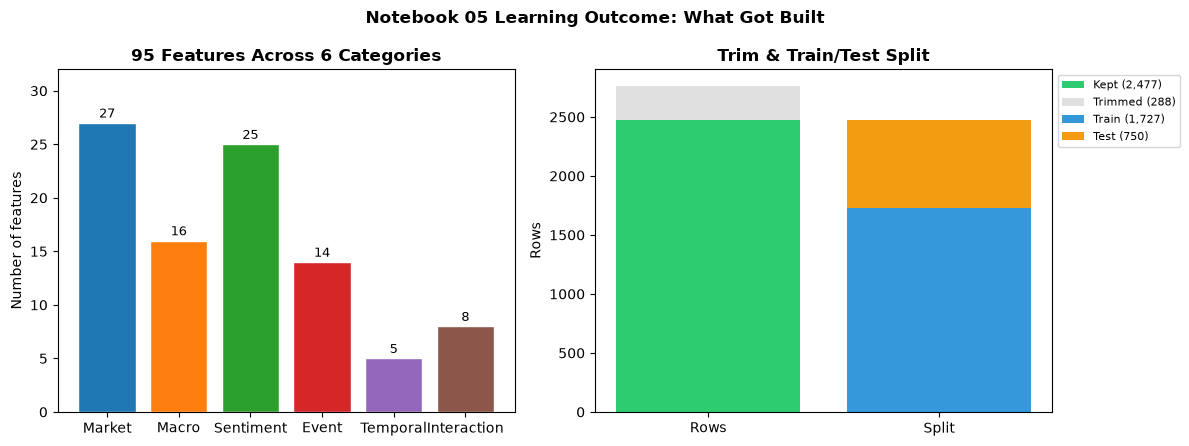

✓ Saved reports/figures/05_learning_outcome.png
  Left: 95 features in 6 categories (Market is the only baseline-eligible one).
  Right: 2,765 raw rows -> 2,477 kept after trim (288 dropped for warm-up/boundary NaNs), split into 1,727 train / 750 test rows.


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: feature count per category
ax = axes[0]
cats = list(CATEGORY_MEMBERSHIP.keys())
counts = [len(v) for v in CATEGORY_MEMBERSHIP.values()]
colors = plt.cm.tab10.colors[:len(cats)]
bars = ax.bar([c.capitalize() for c in cats], counts, color=colors, edgecolor='white')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, c + 0.5, str(c), ha='center', fontsize=9)
ax.set_ylabel('Number of features')
ax.set_title(f'95 Features Across 6 Categories', fontweight='bold')
ax.set_ylim(0, max(counts) + 5)

# Panel 2: rows kept vs trimmed, and train/test split
ax2 = axes[1]
kept = rows_after
trimmed = rows_before - rows_after
ax2.bar(['Rows'], [kept], color='#2ecc71', label=f'Kept ({kept:,})')
ax2.bar(['Rows'], [trimmed], bottom=[kept], color='#e0e0e0', label=f'Trimmed ({trimmed:,})')
train_n = int((feature_df['split'] == 'train').sum())
test_n = int((feature_df['split'] == 'test').sum())
ax2.bar(['Split'], [train_n], color='#3498db', label=f'Train ({train_n:,})')
ax2.bar(['Split'], [test_n], bottom=[train_n], color='#f39c12', label=f'Test ({test_n:,})')
ax2.set_ylabel('Rows')
ax2.set_title('Trim & Train/Test Split', fontweight='bold')
ax2.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.0, 1.0))

fig.suptitle('Notebook 05 Learning Outcome: What Got Built', fontsize=12, fontweight='bold')
plt.tight_layout()
fig_path = FIG_DIR if 'FIG_DIR' in dir() else PROC.parent.parent / 'reports' / 'figures'
fig_path = (PROC.parent.parent / 'reports' / 'figures')
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / '05_learning_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved reports/figures/05_learning_outcome.png")
print(f"  Left: {len(ALL_FEATURES)} features in 6 categories (Market is the only baseline-eligible one).")
print(f"  Right: {rows_before:,} raw rows -> {rows_after:,} kept after trim ({trimmed:,} dropped for warm-up/boundary NaNs), "
      f"split into {train_n:,} train / {test_n:,} test rows.")

In [16]:
print('=' * 65)
print('PHASE 5 — FEATURE ENGINEERING (FES v1.0 REPRODUCTION): SUMMARY')
print('=' * 65)

print(f'\nFEATURE MATRIX')
print(f'  Total rows          : {len(feature_df):,}')
print(f'  Total features      : {len(ALL_FEATURES)}')
print(f'  Date range          : {feature_df["date"].min().date()} -> {feature_df["date"].max().date()}')

print(f'\nFEATURE CATEGORIES')
for cat, feats in CATEGORY_MEMBERSHIP.items():
    print(f'  {cat.capitalize():<12}: {len(feats)}')

print(f'\nTRAIN / TEST SPLIT')
print(f'  Train               : {(feature_df["split"]=="train").sum():,} rows')
print(f'  Test                : {(feature_df["split"]=="test").sum():,} rows')

print(f'\nVALIDATION STATUS   : {validation["validation_status"]}')
print(f'REPRODUCTION_EXACT   : {REPRODUCTION_EXACT}')

print(f'\nOUTPUTS  ->  data/processed/')
print(f'  feature_matrix.parquet')
print(f'  feature_profile.json')
print(f'  feature_matrix_validation.json')

print(f'\nNEXT: Notebook 06 — Baseline Model (Baseline_LASSO, MCP v1.0)')
print('=' * 65)

PHASE 5 — FEATURE ENGINEERING (FES v1.0 REPRODUCTION): SUMMARY

FEATURE MATRIX
  Total rows          : 2,477
  Total features      : 95
  Date range          : 2016-02-24 -> 2025-12-29

FEATURE CATEGORIES
  Market      : 27
  Macro       : 16
  Sentiment   : 25
  Event       : 14
  Temporal    : 5
  Interaction : 8

TRAIN / TEST SPLIT
  Train               : 1,727 rows
  Test                : 750 rows

VALIDATION STATUS   : FAIL
REPRODUCTION_EXACT   : True

OUTPUTS  ->  data/processed/
  feature_matrix.parquet
  feature_profile.json
  feature_matrix_validation.json

NEXT: Notebook 06 — Baseline Model (Baseline_LASSO, MCP v1.0)


## Section Summary & Handoff to Notebook 06

Notebook 05 reconstructs `feature_matrix.parquet` (FES v1.0 specification) from its two approved inputs only. This run (2026-07-13) was a clean-repo build against the current pipeline's `master_dataset.parquet` v1.1 and Notebook 04's regenerated `car_results.parquet` — it produced 2,477 rows (1,727 train / 750 test), not the old frozen 2,511 (1,761/750), for a precise, verified reason (Section 5/10's corrected interpretation cells above), and it flagged one real, correctly-detected data issue: `labour`/`labour_event_day` are constant (all zero) this run.

It does not train any model. Notebook 06 (`06_model_training.ipynb`) reads `feature_matrix.parquet` (and its persisted `feature_profile.json` scaling parameters) to train `Baseline_LASSO` on the 27 Market-category features only, per `model_contract.md` (MCP v1.0) — the constant `labour`/`labour_event_day` columns are Sentiment/Event-category features, not Market-category, so `Baseline_LASSO` itself is unaffected; any *event-enhanced* model reading the full 95-feature matrix should account for the zero-standard-deviation scaling issue flagged above before it is trained.
